# GRF vs OLS Horserace
Comparison of CausalForest (from `grf.py`) against OLS with linear interactions on synthetic data with heterogeneous treatment effects.

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import importlib

if "." not in sys.path:
    sys.path.insert(0, ".")

import grf
importlib.reload(grf)
from grf import CausalForest

np.random.seed(123)

In [7]:
# Synthetic data generation
n = 5000    ## number of samples
p = 2       ## number of covariates
X = np.random.normal(size=(n, p))


## Baseline outcome is linear in covariates
Y0 = np.dot(X, np.arange(-1, -1+p, 1)) +\
        np.random.normal(scale=1.0, size=n)

## true heterogeneous treatment effect which is 
## non-linear in the first two covariates
tau_true = 0.50 * np.sin(X[:, 0]).astype(float) +\
           0.75 * X[:,1]

## treatment propensity depends on X[:,2] (so not randomized completely)
prop =  np.dot(X, np.arange(-1, -1+p, 1)) +\
        np.random.normal(scale=1.0, size=n)
W = (prop > np.median(prop)).astype(float)

## observed outcome 
Y = Y0 + W * tau_true

# split into train/test
X_train, X_test, Y_train, Y_test, W_train, W_test, tau_train, tau_test = train_test_split(
    X, Y, W, tau_true, test_size=0.5, random_state=1
)

print(f"Data shape: n={n}, p={p}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Data shape: n=5000, p=2
Train: 2500, Test: 2500


In [ ]:
# Fit the causal forest (from grf.py) on the training set
cf = CausalForest(
    n_trees=500,
    # sample_fraction=None,
    # honesty_fraction=None,
    # min_node_size=None,
    max_depth=20,
    random_state=42
)

print("Fitting CausalForest...")
cf.fit(X_train, Y_train, W_train)
print("Predicting with CausalForest on test set...")
tau_cf_test, tau_cf_se = cf.predict(X_test)
print("CausalForest: first 5 tau estimates (test):", np.round(tau_cf_test[:5], 3))
print("CausalForest: first 5 tau SE (test):", np.round(tau_cf_se[:5], 3))

Fitting CausalForest...
Predicting with CausalForest on test set...
CausalForest: first 5 tau estimates (test): [ 1.274 -0.459  0.397 -0.587 -0.223]
CausalForest: first 5 tau SE (test): [0.062 0.052 0.047 0.039 0.049]


In [9]:
def mse(a, b):
    return np.mean((a - b) ** 2)
mse_cf = mse(tau_cf_test, tau_test)
print(f"MSE (CausalForest)     = {mse_cf:.4f}")


MSE (CausalForest)     = 0.1297


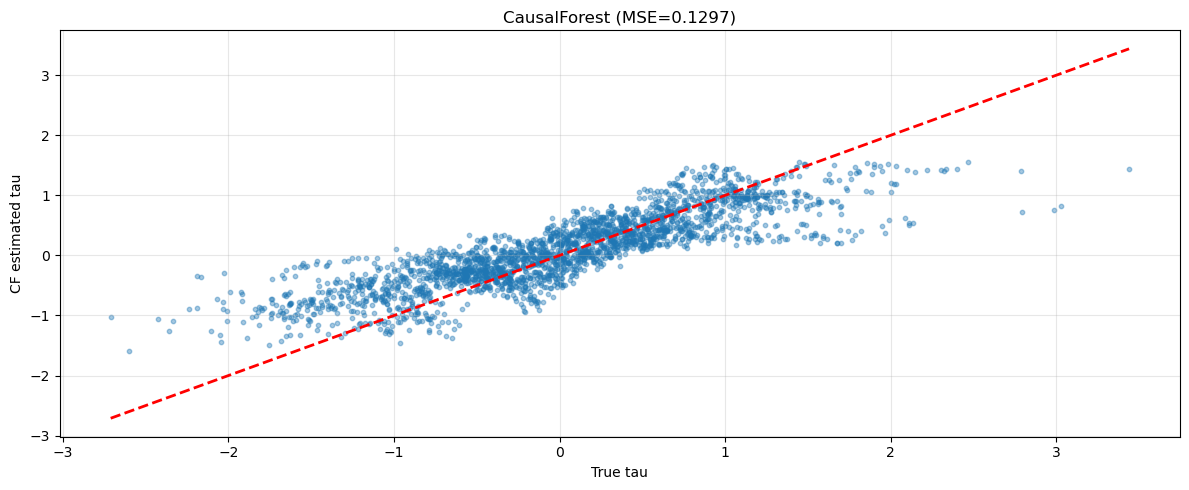

In [13]:
fig, axes = plt.subplots(1, 1, figsize=(12, 5))
axes.scatter(tau_test, tau_cf_test, alpha=0.4, s=10)
axes.plot([tau_test.min(), tau_test.max()], [tau_test.min(), tau_test.max()], "r--", linewidth=2)
axes.set_xlabel("True tau")
axes.set_ylabel("CF estimated tau")
axes.set_title(f"CausalForest (MSE={mse_cf:.4f})")
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
